# Domain Shift Audit

Inspect how hybrid and paired units differ in the current feature space before choosing the next modeling move.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

repo_root = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

from crash_tests.domain_shift_audit import DomainShiftAuditConfig, run_with_config

In [2]:
RUN_NAME = 'domain_shift_notebook_v1'

config = DomainShiftAuditConfig(
    parquet_path=repo_root / 'data/raw/33000_ROWS.parquet',
    output_root=repo_root / 'crash_tests/domain_shift_audit/outputs',
    run_name=RUN_NAME,
    verbose=True,
)

config

DomainShiftAuditConfig(parquet_path=PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/data/raw/33000_ROWS.parquet'), output_root=PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/crash_tests/domain_shift_audit/outputs'), run_name='domain_shift_notebook_v1', random_state=42, paired_final_holdout_rows=100, top_n_features=30, max_domain_rows_for_classifier=5000, pca_rows_per_domain=1500, verbose=True)

## Run

This cell writes CSV artifacts under the configured output directory and prints progress while computing feature drift and domain separability.

In [3]:
output_dir = run_with_config(config)
output_dir

Loading parquet from /Users/paulruiz/Documents/Predicting_Good_Units/data/raw/33000_ROWS.parquet
Computing feature drift for hybrid_vs_paired_all
Computing feature drift for hybrid_vs_paired_matched
Computing feature drift for hybrid_vs_paired_unmatched
Computing feature drift for hybrid_vs_paired_finetune
Computing feature drift for hybrid_vs_paired_test
Computing feature drift for paired_matched_vs_unmatched
Computing feature drift for paired_finetune_vs_test
Training domain classifier for hybrid_vs_paired_all [unit]
Training domain classifier for hybrid_vs_paired_all [full_context]
Training domain classifier for hybrid_vs_paired_test [unit]
Training domain classifier for hybrid_vs_paired_test [full_context]
Saved outputs to /Users/paulruiz/Documents/Predicting_Good_Units/crash_tests/domain_shift_audit/outputs/domain_shift_notebook_v1


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/crash_tests/domain_shift_audit/outputs/domain_shift_notebook_v1')

In [4]:
feature_shift = pd.read_csv(output_dir / 'feature_shift_summary.csv')
group_summary = pd.read_csv(output_dir / 'feature_group_summary.csv')
classifier_summary = pd.read_csv(output_dir / 'domain_classifier_summary.csv')
classifier_coefs = pd.read_csv(output_dir / 'domain_classifier_coefficients.csv')
study_shift = pd.read_csv(output_dir / 'study_shift_summary.csv')
pca_projection = pd.read_csv(output_dir / 'pca_projection.csv')

display(Markdown('## Domain Classifier Summary'))
display(classifier_summary)

display(Markdown('## Top Shifted Features: Hybrid vs Paired (Unit)'))
display(feature_shift.query("comparison == 'hybrid_vs_paired_all' and feature_set == 'unit'").head(25))

display(Markdown('## Highest-Shift Feature Groups'))
display(group_summary.groupby(['comparison', 'feature_set'], group_keys=False).head(8))

display(Markdown('## Study-Level Shift Summary'))
display(study_shift)

display(Markdown('## Top Domain-Separating Coefficients'))
display(classifier_coefs.groupby(['comparison', 'feature_set'], group_keys=False).head(20))

## Domain Classifier Summary

,comparison,feature_set,rows_a,rows_b,n_features,cv_auc_mean,cv_auc_std
0,hybrid_vs_paired_all,unit,5000,5000,164,0.976470,0.046301
1,hybrid_vs_paired_all,full_context,5000,5000,685,0.999738,0.000524
2,hybrid_vs_paired_test,unit,5000,100,164,0.999653,0.000694
3,hybrid_vs_paired_test,full_context,5000,100,685,1.000000,0.000000


## Top Shifted Features: Hybrid vs Paired (Unit)

,comparison,feature_set,feature,feature_group,rows_a,rows_b,mean_a,mean_b,median_a,median_b,std_a,std_b,missing_a,missing_b,missing_gap,smd,abs_smd,ks_stat,wasserstein
0,hybrid_vs_paired_all,unit,wf_trough_to_peak_ms,other,24211,8982,0.316064,0.987370,0.300000,1.000000,0.129534,0.346640,0.000000,0.316522,0.316522,2.565506,2.565506,0.855587,0.671377
1,hybrid_vs_paired_all,unit,snr,other,24211,8982,6.296288,4.359456,6.323245,4.154409,0.706945,0.840446,0.000000,0.000000,0.000000,-2.494088,2.494088,0.798997,1.936939
2,hybrid_vs_paired_all,unit,wf_bin_17,waveform_bins,24211,8982,0.342738,-0.400036,0.401019,-0.438988,0.255795,0.340791,0.000000,0.000000,0.000000,-2.465191,2.465191,0.832985,0.742774
3,hybrid_vs_paired_all,unit,wf_bin_16,waveform_bins,24211,8982,0.107535,-0.592250,0.061617,-0.667633,0.311771,0.310808,0.000000,0.000000,0.000000,-2.248021,2.248021,0.812836,0.699786
4,hybrid_vs_paired_all,unit,wf_peak_trough_ms,other,24211,8982,0.275093,0.954984,0.233333,1.000000,0.124084,0.429318,0.000000,0.000000,0.000000,2.151560,2.151560,0.788150,0.679906
5,hybrid_vs_paired_all,unit,wf_bin_18,waveform_bins,24211,8982,0.326925,-0.265052,0.322178,-0.269390,0.175067,0.356671,0.000000,0.000000,0.000000,-2.107074,2.107074,0.809164,0.595316
6,hybrid_vs_paired_all,unit,wf_zero_cross_post_ms,other,24211,8982,0.171209,0.535986,0.166667,0.550000,0.070743,0.244641,0.000000,0.316522,0.316522,2.025697,2.025697,0.795711,0.368854
7,hybrid_vs_paired_all,unit,wf_line_length_norm,other,24211,8982,3.773370,2.248177,3.643519,2.391740,0.725403,0.879276,0.000000,0.000000,0.000000,-1.892253,1.892253,0.842896,1.525193
8,hybrid_vs_paired_all,unit,wf_curvature_norm,other,24211,8982,2.866877,1.206687,2.477187,1.028070,1.267634,0.798905,0.000000,0.000000,0.000000,-1.566934,1.566934,0.769166,1.660190
9,hybrid_vs_paired_all,unit,wf_bin_19,waveform_bins,24211,8982,0.251353,-0.169769,0.219805,-0.147550,0.150345,0.367637,0.000000,0.000000,0.000000,-1.499421,1.499421,0.724682,0.428628


## Highest-Shift Feature Groups

,comparison,feature_set,feature_group,n_features,mean_abs_smd,median_abs_smd,max_abs_smd,mean_ks,mean_missing_gap
0,hybrid_vs_paired_all,context_only,recording_context,470,5.184643e-01,0.293348,5.305377e+00,0.400013,0.001440
1,hybrid_vs_paired_all,context_only,recording_relative,51,7.173363e-17,0.000000,3.855413e-16,0.014612,0.006651
2,hybrid_vs_paired_all,full_context,other,41,7.339956e-01,0.656970,2.565506e+00,0.533463,0.044855
3,hybrid_vs_paired_all,full_context,waveform_bins,30,7.107847e-01,0.471606,2.465191e+00,0.521906,0.000000
4,hybrid_vs_paired_all,full_context,amplitude,23,5.389827e-01,0.608839,1.401867e+00,0.581063,0.000347
...,...,...,...,...,...,...,...,...,...
121,paired_matched_vs_unmatched,unit,confusability,15,1.768627e-01,0.096600,7.487841e-01,0.128687,-0.001796
122,paired_matched_vs_unmatched,unit,waveform_bins,30,1.212616e-01,0.132090,1.916421e-01,0.129715,0.000000
123,paired_matched_vs_unmatched,unit,acg_bins,40,1.080628e-01,0.077192,3.018378e-01,0.147794,0.000000
124,paired_matched_vs_unmatched,unit,amplitude,23,1.069922e-01,0.108157,2.508199e-01,0.191737,0.001254


## Study-Level Shift Summary

,study_set,feature_set,rows,recordings,matched_rows,mean_abs_smd,median_abs_smd,max_abs_smd,top_shifted_features
0,PAIRED_BOYDEN,unit,907,4,43,1.134667,0.700280,5.609137,amp_std|amp_iqr|amp_p95|median_cosine|wf_bin_1...
1,PAIRED_KAMPFF,unit,1743,4,35,1.100682,0.681055,3.171131,median_cosine|wf_bin_17|wf_bin_16|wf_bin_18|sn...
2,PAIRED_MEA64C_YGER,unit,2997,4,36,0.978555,0.419130,4.455740,snr|wf_trough_to_peak_ms|wf_peak_trough_ms|wf_...
3,PAIRED_CRCNS_HC1,unit,184,4,22,0.934401,0.622188,3.998298,wf_peak_trough_ms|amp_late_p50|wf_trough_to_pe...
4,PAIRED_ENGLISH,unit,3151,15,71,0.507118,0.328368,2.408175,si_snr|amp_bin_cv_mean|center_of_mass_um|peak_...
5,PAIRED_CRCNS_HC1,full_context,184,4,22,2.092038,0.629618,43.878959,amp_mean_recording_mean|template_norm_recordin...
6,PAIRED_BOYDEN,full_context,907,4,43,1.937641,0.601254,34.580540,si_amplitude_median_recording_std|amp_std_reco...
7,PAIRED_MEA64C_YGER,full_context,2997,4,36,1.115772,0.421290,34.999489,snr_recording_mean|snr_recording_median|snr_re...
8,PAIRED_KAMPFF,full_context,1743,4,35,1.015113,0.321065,7.673772,snr_recording_iqr|snr_recording_median|snr_rec...
9,PAIRED_ENGLISH,full_context,3151,15,71,0.716148,0.346859,11.536242,si_snr_recording_mean|si_snr_recording_median|...


## Top Domain-Separating Coefficients

,comparison,feature_set,feature,feature_group,coef,abs_coef,direction
0,hybrid_vs_paired_all,unit,std_cosine,confusability,1.723623,1.723623,paired_up
1,hybrid_vs_paired_all,unit,n_channels,other,1.653477,1.653477,paired_up
2,hybrid_vs_paired_all,unit,peak_to_trough_uv,other,1.473696,1.473696,paired_up
3,hybrid_vs_paired_all,unit,mean_neighbor_dist_um,confusability,-1.379205,1.379205,hybrid_up
4,hybrid_vs_paired_all,unit,repolarization_slope,other,1.312459,1.312459,paired_up
...,...,...,...,...,...,...,...
105,hybrid_vs_paired_test,full_context,amp_late_p50,amplitude,0.262588,0.262588,paired_up
106,hybrid_vs_paired_test,full_context,template_norm_recording_median,recording_context,0.262124,0.262124,paired_up
107,hybrid_vs_paired_test,full_context,amp_bin_cv_mean_recording_mean,recording_context,0.261596,0.261596,paired_up
108,hybrid_vs_paired_test,full_context,si_amplitude_cv_median_recording_median,recording_context,0.261014,0.261014,paired_up


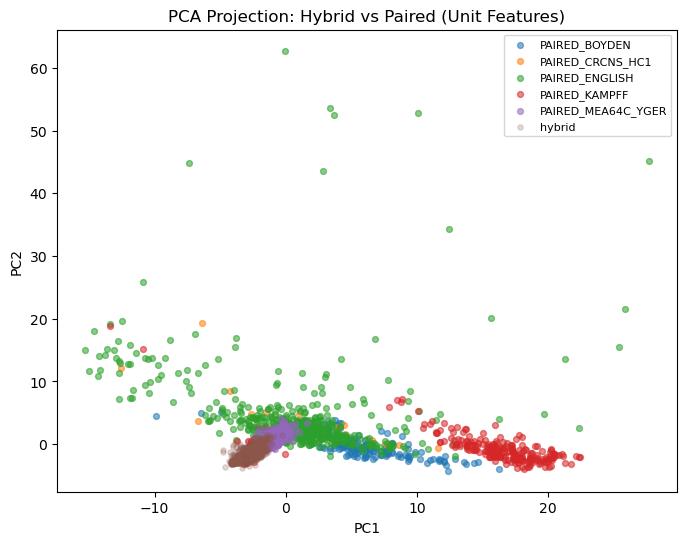

In [5]:
plot_df = pca_projection.copy()
plot_df['domain_label'] = plot_df['dataset_type'].where(plot_df['dataset_type'] == 'hybrid', plot_df['study_set'])

fig, ax = plt.subplots(figsize=(8, 6))
for label, grp in plot_df.groupby('domain_label'):
    alpha = 0.22 if label == 'hybrid' else 0.55
    size = 14 if label == 'hybrid' else 18
    ax.scatter(grp['pc1'], grp['pc2'], s=size, alpha=alpha, label=label)
ax.set_title('PCA Projection: Hybrid vs Paired (Unit Features)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='best', fontsize=8)
plt.show()